In [56]:
from accelforge import Spec, examples
from pathlib import Path

In [57]:
def get_energy(result):
    """Get total energy in pJ."""
    return float(result.energy())


def get_cycles(result):
    """Get total latency in cycles."""
    return float(result.latency())


def get_component_energy(result, component):
    """Get energy for a specific component."""
    energy = result.energy(per_component=True)
    return float(energy.get(component, 0))

In [81]:
P_1_QK_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU_QK.yaml",
    "../workloads/C_4/flash_attention_C_4_QK.yaml"
)
P_1_QK_results = P_1_QK_spec.map_workload_to_arch()

Getting energy, latency, and leak power for components running QK_1: 100%|█| 1/1 [00:00<00:00, 2
Generating jobs:   0%|                                                    | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK_1: 0it [00:00, ?it/s]

Generating pmapping templates for compute MXU Einsum QK_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 10it [00:00, 98.44it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 20it [00:00, 99.10it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 32it [00:00, 96.31it/s]
Generating jobs: 100%|████████████████████████████████████████████| 1/1 [00:00<00:00,  2.57it/s]


Einsum QK_1 has 32 pmapping jobs:
	0	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  S-reuse_weight2-e  S-reuse_weight1-m_chunk  [K_1 in MxuBuffer] T-m  [QK_1 in MxuBuffer] T-e  MXU computes QK_1
	1	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-h  T-m  T-m_chunk  S-reuse_weight2-e  S-reuse_weight1-m_chunk  [QK_1 in MxuBuffer] T-e  [K_1 in MxuBuffer] T-m  MXU computes QK_1
	2	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  [K_1 in GlobalBuffer] S-reuse_weight2-e  S-reuse_weight1-m_chunk  [K_1 in MxuBuffer] T-m  [QK_1 in MxuBuffer] T-e  MXU computes QK_1
	3	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  [K_1 in GlobalBuffer] T-m  S-reuse_weight2-e  S-reuse_weight1-m_chunk  [QK_1 in MxuBuffer] T-e  [K_1 in MxuBuffer] T-m  MXU computes QK_1
	4	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m  [Q in GlobalBuffer] T-m_chunk  S-reuse_

Compressing pmappings: 100%|█████████████████████████████████████| 1/1 [00:00<00:00, 425.39it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|██████████████████████████████████| 1/1 [00:00<00:00, 1296.94it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=2.20e-03
Final clean join.


Dirty pruning pmappings: 100%|██████████████████████████████████| 1/1 [00:00<00:00, 1521.88it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|████████████████████████████████████████| 1/1 [00:00<00:00, 9619.96it/s]


Dirty joining mapping(s) valid & optimal! Returning...


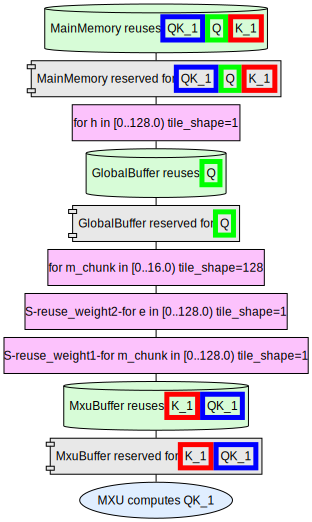

In [82]:
P_1_QK_results

In [83]:
print("Total Cycles: ", get_cycles(P_1_QK_results))
print("Total Energy: ", get_energy(P_1_QK_results))
print("MainMemory: ", get_component_energy(P_1_QK_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(P_1_QK_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(P_1_QK_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(P_1_QK_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(P_1_QK_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(P_1_QK_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(P_1_QK_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(P_1_QK_results, 'MXU'))

Total Cycles:  5.5102540500229225e-05
Total Energy:  0.0022008202139160073
MainMemory:  0.0019027655944228172
GlobalBuffer:  4.251975679900847e-06

ScalarBuffer:  0.0
ScalarUnit:  0.0

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  0.0002909840371918643
MXU:  2.818572288e-06


In [61]:
P_1_AV_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU_AV.yaml",
    "../workloads/C_4/flash_attention_C_4_AV.yaml"
)
P_1_AV_results = P_1_AV_spec.map_workload_to_arch()

Getting energy, latency, and leak power for components running AV_1: 100%|█| 1/1 [00:00<00:00, 2
Generating jobs:   0%|                                                    | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum AV_1: 0it [00:00, ?it/s]

Generating pmapping templates for compute MXU Einsum AV_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute MXU Einsum AV_1: 9it [00:00, 77.82it/s]
Generating pmapping templates for compute MXU Einsum AV_1: 17it [00:00, 78.51it/s]
Generating pmapping templates for compute MXU Einsum AV_1: 32it [00:00, 83.57it/s]

Generating pmapping templates for compute VPU Einsum AV_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute VPU Einsum AV_1: 11it [00:00, 104.72it/s]
Generating pmapping templates for compute VPU Einsum AV_1: 32it [00:00, 103.33it/s]
Generating jobs: 100%|████████████████████████████████████████████| 1/1 [00:00<00:00,  1.29it/s]


Einsum AV_1 has 64 pmapping jobs:
	0	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  T-e  T-h  T-m  S-reuse_weight2-m_chunk  S-reuse_weight1-e  [AV_1 in MxuBuffer] T-m_chunk  [V_1 in MxuBuffer] T-m  MXU computes AV_1
	1	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  S-reuse_weight2-m_chunk  S-reuse_weight1-e  [V_1 in MxuBuffer] T-m  [AV_1 in MxuBuffer] T-m_chunk  MXU computes AV_1
	2	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  T-e  T-h  T-m  [AV_1 in GlobalBuffer] S-reuse_weight2-m_chunk  S-reuse_weight1-e  [AV_1 in MxuBuffer] T-m_chunk  [V_1 in MxuBuffer] T-m  MXU computes AV_1
	3	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  T-e  T-h  T-m  [AV_1 in GlobalBuffer] T-m_chunk  S-reuse_weight2-m_chunk  S-reuse_weight1-e  [V_1 in MxuBuffer] T-m  [AV_1 in MxuBuffer] T-m_chunk  MXU computes AV_1
	4	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  

Compressing pmappings: 100%|█████████████████████████████████████| 1/1 [00:00<00:00, 518.71it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|██████████████████████████████████| 1/1 [00:00<00:00, 1664.41it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=2.20e-03
Final clean join.


Dirty pruning pmappings: 100%|██████████████████████████████████| 1/1 [00:00<00:00, 1675.04it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|███████████████████████████████████████| 1/1 [00:00<00:00, 11491.24it/s]


Dirty joining mapping(s) valid & optimal! Returning...


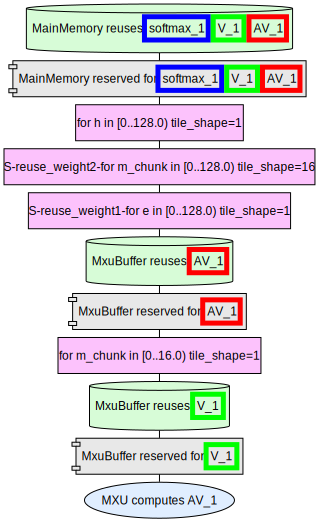

In [62]:
P_1_AV_results

In [63]:
print("Total Cycles: ", get_cycles(P_1_AV_results))
print("Total Energy: ", get_energy(P_1_AV_results))
print("MainMemory: ", get_component_energy(P_1_AV_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(P_1_AV_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(P_1_AV_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(P_1_AV_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(P_1_AV_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(P_1_AV_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(P_1_AV_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(P_1_AV_results, 'MXU'))

Total Cycles:  5.5102540500229225e-05
Total Energy:  0.0021965682515190693
MainMemory:  0.0019027656202113324
GlobalBuffer:  0.0

ScalarBuffer:  0.0
ScalarUnit:  0.0

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  0.00029098404446782194
MXU:  2.818572288e-06


In [98]:
P_1_ACC_spec = Spec.from_yaml(
    "../arches/tpu_v4i_only_VPU.yaml",
    "../workloads/C_4/flash_attention_C_4_ACC.yaml"
)
P_1_ACC_results = P_1_ACC_spec.map_workload_to_arch()

Getting energy, latency, and leak power for components running AV_accum_1: 100%|█| 1/1 [00:00<00
Generating jobs:   0%|                                                    | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum AV_accum_1: 0it [00:00, ?it/s]

Generating pmapping templates for compute VPU Einsum AV_accum_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute VPU Einsum AV_accum_1: 16it [00:00, 98.21it/s]
Generating jobs: 100%|████████████████████████████████████████████| 1/1 [00:00<00:00,  4.59it/s]


Einsum AV_accum_1 has 16 pmapping jobs:
	0	[AV_accum_1 in MainMemory] [AV_1 in MainMemory] [AV_0 in MainMemory] T-b  T-e  T-h  T-m  S-reuse_input-m  S-reuse_input-h  S-reuse_input-e  S-reuse_input-b  [AV_accum_1 in VpuBuffer] VPU computes AV_accum_1
	1	[AV_accum_1 in MainMemory] [AV_1 in MainMemory] [AV_0 in MainMemory] T-b  T-e  T-h  T-m  [AV_0 in GlobalBuffer] S-reuse_input-m  S-reuse_input-h  S-reuse_input-e  S-reuse_input-b  [AV_accum_1 in VpuBuffer] VPU computes AV_accum_1
	2	[AV_accum_1 in MainMemory] [AV_1 in MainMemory] [AV_0 in MainMemory] T-b  T-e  T-h  T-m  [AV_1 in GlobalBuffer] S-reuse_input-m  S-reuse_input-h  S-reuse_input-e  S-reuse_input-b  [AV_accum_1 in VpuBuffer] VPU computes AV_accum_1
	3	[AV_accum_1 in MainMemory] [AV_1 in MainMemory] [AV_0 in MainMemory] T-b  T-e  T-h  T-m  [AV_accum_1 in GlobalBuffer] S-reuse_input-m  S-reuse_input-h  S-reuse_input-e  S-reuse_input-b  [AV_accum_1 in VpuBuffer] VPU computes AV_accum_1
	4	[AV_accum_1 in MainMemory] [AV_1 in MainMe

Compressing pmappings: 100%|█████████████████████████████████████| 1/1 [00:00<00:00, 245.40it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|███████████████████████████████████| 1/1 [00:00<00:00, 887.31it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=2.13e-06
Final clean join.


Dirty pruning pmappings: 100%|███████████████████████████████████| 1/1 [00:00<00:00, 582.06it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|███████████████████████████████████████| 1/1 [00:00<00:00, 11008.67it/s]


Dirty joining mapping(s) valid & optimal! Returning...


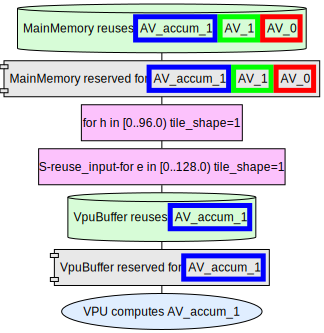

In [99]:
P_1_ACC_results

In [100]:
print("Total Cycles: ", get_cycles(P_1_ACC_results))
print("Total Energy: ", get_energy(P_1_ACC_results))
print("MainMemory: ", get_component_energy(P_1_ACC_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(P_1_ACC_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(P_1_ACC_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(P_1_ACC_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(P_1_ACC_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(P_1_ACC_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(P_1_ACC_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(P_1_ACC_results, 'MXU'))

Total Cycles:  9.142857493316114e-08
Total Energy:  2.1304442731169964e-06
MainMemory:  2.0732313448751486e-06
GlobalBuffer:  0.0

ScalarBuffer:  0.0
ScalarUnit:  0.0

VpuBuffer:  5.328076824184791e-08
VPU:  3.93216e-09

MxuBuffer:  0.0
MXU:  0.0
